# Farmyard Sound Event Detection System

This notebook provides a complete end-to-end workflow for training and evaluating a sound event detection system for farm yard animal sounds.

In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:")
!ls -la

Current working directory: /content
Files in current directory:
total 20
drwxr-xr-x 1 root root 4096 Jul 15 17:56 .
drwxr-xr-x 1 root root 4096 Jul 15 17:46 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:32 .config
drwxr-xr-x 3 root root 4096 Jul 15 17:56 data
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data


In [3]:
# Install required packages
print("Installing dependencies...")
!pip install -q -r requirements.txt
print("Dependencies installed successfully!")

Installing dependencies...
Dependencies installed successfully!


## Step 1: Explore or Generate Training Data

We'll first check if we have any existing data in the `sample_data/` directory. If not, or if you want more data, we'll generate synthetic training data.

In [4]:
import os
import zipfile
from pathlib import Path

# 1. Find the zip file (assuming there's one main zip file in the current directory)
zip_files = list(Path(".").glob("*.zip"))

if not zip_files:
    print("No .zip file found in the current directory.")
else:
    # Take the first zip file found
    zip_path = zip_files[0]
    print(f"Found zip file: {zip_path.name}")

    # 2. Unzip the file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

    # 3. Handle the "same name folder" issue
    # The zip will likely create a folder named exactly like the zip file (minus .zip)
    expected_nested_folder = zip_path.stem

    if Path(expected_nested_folder).is_dir():
        # Navigate into that nested folder to find the real data
        real_data_path = Path(expected_nested_folder)
        print(f"Found nested folder '{expected_nested_folder}', looking inside for data...")
    else:
        # Fallback: if it unzipped flatly or with a different name, just use current directory
        real_data_path = Path(".")

    # 4. Check what's in the real data directory (look for subfolders containing .wav files)
    print(f"\nContents of real data path ({real_data_path}/):")

    # We look specifically for class directories inside the real data path
    class_dirs_found = False
    for class_dir in sorted(real_data_path.iterdir()):
        if class_dir.is_dir() and not class_dir.name.startswith('__MACOSX') and not class_dir.name.startswith('.'):
            n_files = len(list(class_dir.glob("*.wav")))
            if n_files > 0:
                print(f"  {class_dir.name}: {n_files} files")
                class_dirs_found = True

    if not class_dirs_found:
        print("  No directories containing .wav files were found.")
        print("  (Showing all items in the folder instead):")
        for item in sorted(real_data_path.iterdir()):
            prefix = "📁 " if item.is_dir() else "📄 "
            print(f"    {prefix}{item.name}")

Found zip file: dataset.zip
Found nested folder 'dataset', looking inside for data...

Contents of real data path (dataset/):
  cat: 40 files
  cow: 40 files
  dog: 40 files
  others: 80 files
  rooster: 40 files
  sheep: 40 files


### Option A: Use Existing Data (if you have some)
If you have audio files organized by class in `sample_data/`, you can use them directly.

### Option B: Generate Synthetic Data
We'll generate a small synthetic dataset for quick demonstration. You can increase the number of recordings for better performance.

In [5]:
import os
import shutil
import random
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional


class PreSplitSyntheticGenerator:
    """
    Generates synthetic data with proper train/val/test pre-splitting.

    Key features to prevent data leakage:
    1. Real data is split FIRST, before any processing
    2. Synthetic data for each split is generated ONLY from files in that split
    3. No information flows between splits at any point
    4. Real and synthetic files are clearly labeled
    """

    SUPPORTED_EXTENSIONS = {'.wav', '.mp3', '.flac', '.ogg', '.aiff'}

    def __init__(
        self,
        source_dir: str,
        output_dir: str,
        sample_rate: int = 16000,
        seed: int = 42
    ):
        self.source_dir = Path(source_dir)
        self.output_dir = Path(output_dir)
        self.sample_rate = sample_rate
        self.seed = seed

        # Set seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)

        # Storage for file catalog and splits
        self.file_catalog: Dict[str, List[str]] = {}
        self.splits: Dict[str, Dict[str, List[str]]] = {}

        # Create output directory
        self.output_dir.mkdir(parents=True, exist_ok=True)

        # Save split metadata for reproducibility
        self.split_metadata = {
            'seed': seed,
            'source_dir': str(source_dir),
            'split_ratios': None,
            'splits': {}
        }

    def scan_source_data(self) -> Dict[str, List[str]]:
        """
        Scan source directories and catalog all audio files by class.
        Returns a dictionary mapping class names to lists of file paths.
        """
        self.file_catalog = defaultdict(list)

        if not self.source_dir.exists():
            raise FileNotFoundError(f"Source directory not found: {self.source_dir}")

        # Look for class folders (subdirectories)
        for class_dir in sorted(self.source_dir.iterdir()):
            if class_dir.is_dir():
                class_name = class_dir.name
                # Skip hidden directories
                if class_name.startswith('.'):
                    continue

                # Find all supported audio files
                for ext in self.SUPPORTED_EXTENSIONS:
                    for audio_file in class_dir.glob(f'**/*{ext}'):
                        self.file_catalog[class_name].append(str(audio_file))

        # Convert to regular dict and sort file lists for reproducibility
        self.file_catalog = {
            k: sorted(v) for k, v in sorted(self.file_catalog.items())
        }

        total_files = sum(len(v) for v in self.file_catalog.values())
        print(f"Found {total_files} audio files across {len(self.file_catalog)} classes:")
        for class_name, files in self.file_catalog.items():
            print(f"  • {class_name}: {len(files)} files")

        return self.file_catalog

    def stratified_split(
        self,
        split_ratios: Tuple[float, float, float] = (0.7, 0.15, 0.15)
    ) -> Dict[str, Dict[str, List[str]]]:
        """
        Split files into train/val/test sets with stratification by class.
        Each class is split independently to maintain class balance.

        Args:
            split_ratios: (train, val, test) ratios, must sum to 1.0

        Returns:
            Dictionary with 'train', 'val', 'test' keys, each containing
            a dict of class_name -> list of file paths
        """
        if len(split_ratios) != 3:
            raise ValueError("split_ratios must have exactly 3 values (train, val, test)")
        if abs(sum(split_ratios) - 1.0) > 0.01:
            raise ValueError(f"split_ratios must sum to 1.0, got {sum(split_ratios)}")

        self.split_metadata['split_ratios'] = split_ratios

        self.splits = {
            'train': defaultdict(list),
            'val': defaultdict(list),
            'test': defaultdict(list)
        }

        print(f"\nPre-splitting data with ratios: train={split_ratios[0]}, "
              f"val={split_ratios[1]}, test={split_ratios[2]}")
        print("-" * 60)

        for class_name, files in self.file_catalog.items():
            # Create a fresh shuffle with class-specific seed for reproducibility
            class_seed = self.seed + hash(class_name) % 10000
            rng = random.Random(class_seed)
            class_files = files.copy()
            rng.shuffle(class_files)

            n_files = len(class_files)
            n_train = int(n_files * split_ratios[0])
            n_val = int(n_files * split_ratios[1])
            # Test gets the remainder

            self.splits['train'][class_name] = class_files[:n_train]
            self.splits['val'][class_name] = class_files[n_train:n_train + n_val]
            self.splits['test'][class_name] = class_files[n_train + n_val:]

            # Store in metadata
            self.split_metadata['splits'][class_name] = {
                'total': n_files,
                'train': len(self.splits['train'][class_name]),
                'val': len(self.splits['val'][class_name]),
                'test': len(self.splits['test'][class_name])
            }

            print(f"  {class_name}: train={len(self.splits['train'][class_name])}, "
                  f"val={len(self.splits['val'][class_name])}, "
                  f"test={len(self.splits['test'][class_name])}")

        # Convert to regular dicts
        self.splits = {k: dict(v) for k, v in self.splits.items()}

        return self.splits

    def copy_real_data_to_splits(self) -> None:
        """
        Copy real data to split directories, preserving folder structure.
        Files are prefixed with 'real_' to distinguish from synthetic data.
        """
        print("\nCopying real data to split directories...")

        for split_name, class_files in self.splits.items():
            for class_name, files in class_files.items():
                dest_dir = self.output_dir / split_name / class_name
                dest_dir.mkdir(parents=True, exist_ok=True)

                for src_file in files:
                    src_path = Path(src_file)
                    # Prefix with 'real_' to distinguish from synthetic
                    dest_path = dest_dir / f"real_{src_path.stem}{src_path.suffix}"
                    shutil.copy2(src_path, dest_path)

        print("✓ Real data copied to split directories")

    def _load_audio_files(self, file_paths: List[str]) -> List[np.ndarray]:
        """Load audio files using librosa."""
        try:
            import librosa
        except ImportError:
            raise ImportError(
                "librosa is required. Install with: pip install librosa soundfile"
            )

        audio_data = []
        for file_path in file_paths:
            try:
                audio, sr = librosa.load(file_path, sr=self.sample_rate)
                audio_data.append(audio)
            except Exception as e:
                print(f"    Warning: Could not load {file_path}: {e}")

        return audio_data

    def _create_synthetic_sample(
        self,
        source_audio: List[np.ndarray],
        min_duration: float,
        max_duration: float
    ) -> np.ndarray:
        """
        Create a synthetic sample from source audio.
        Uses ONLY the provided source audio (from the same split).

        Techniques used:
        - Random segment selection
        - Segment concatenation
        - Time-domain augmentation
        - Noise injection
        """
        duration = random.uniform(min_duration, max_duration)
        target_length = int(duration * self.sample_rate)

        if not source_audio:
            raise ValueError("No source audio provided")

        # Random number of segments to combine (1-3)
        num_segments = random.randint(1, min(3, len(source_audio)))
        selected_sources = random.choices(source_audio, k=num_segments)

        synthetic = np.zeros(target_length)
        segment_length = target_length // num_segments

        for i, source in enumerate(selected_sources):
            start_idx = i * segment_length
            end_idx = min((i + 1) * segment_length, target_length)
            current_length = end_idx - start_idx

            if current_length <= 0:
                continue

            # Extract random segment from source
            segment = self._extract_random_segment(source, current_length)

            # Apply augmentations
            segment = self._augment_segment(segment)

            synthetic[start_idx:end_idx] += segment

        # Normalize to prevent clipping
        max_val = np.max(np.abs(synthetic))
        if max_val > 0:
            synthetic = synthetic / max_val * 0.9

        return synthetic

    def _extract_random_segment(
        self,
        audio: np.ndarray,
        length: int
    ) -> np.ndarray:
        """Extract a random segment of specified length from audio."""
        if len(audio) >= length:
            start = random.randint(0, len(audio) - length)
            return audio[start:start + length].copy()
        else:
            # Pad if source is shorter than needed
            padded = np.zeros(length)
            padded[:len(audio)] = audio
            return padded

    def _augment_segment(self, segment: np.ndarray) -> np.ndarray:
        """
        Apply random augmentations to prevent exact copying of source data.
        All augmentations are applied in the time domain.
        """
        # Random gain adjustment
        gain = random.uniform(0.5, 1.0)
        segment = segment * gain

        # Random time stretch (simple resampling approach)
        if random.random() > 0.5:
            stretch_factor = random.uniform(0.9, 1.1)
            segment = self._time_stretch_simple(segment, stretch_factor)

        # Add background noise
        if random.random() > 0.3:
            noise_level = random.uniform(0.001, 0.01)
            noise = np.random.randn(len(segment)) * noise_level
            segment = segment + noise

        # Random fade in/out
        if random.random() > 0.5:
            fade_length = min(int(0.1 * self.sample_rate), len(segment) // 4)
            if fade_length > 0:
                fade_in = np.linspace(0, 1, fade_length)
                fade_out = np.linspace(1, 0, fade_length)
                segment[:fade_length] *= fade_in
                segment[-fade_length:] *= fade_out

        return segment

    def _time_stretch_simple(
        self,
        audio: np.ndarray,
        factor: float
    ) -> np.ndarray:
        """Simple time stretch using linear interpolation."""
        original_len = len(audio)
        target_len = int(original_len * factor)

        if target_len <= 0 or target_len > original_len * 2:
            return audio

        # Create interpolation indices
        old_indices = np.linspace(0, original_len - 1, target_len)
        old_indices = np.clip(old_indices, 0, original_len - 1)

        # Interpolate
        floor_indices = np.floor(old_indices).astype(int)
        ceil_indices = np.minimum(floor_indices + 1, original_len - 1)
        weights = old_indices - floor_indices

        stretched = audio[floor_indices] * (1 - weights) + audio[ceil_indices] * weights

        # Resize back to original length
        if len(stretched) >= original_len:
            # Random crop
            max_start = len(stretched) - original_len
            start = random.randint(0, max(0, max_start))
            result = stretched[start:start + original_len]
        else:
            # Pad
            result = np.zeros(original_len)
            start = random.randint(0, original_len - len(stretched))
            result[start:start + len(stretched)] = stretched

        return result

    def generate_synthetic_for_split(
        self,
        split_name: str,
        num_per_class: int,
        min_duration: float = 5.0,
        max_duration: float = 15.0
    ) -> None:
        """
        Generate synthetic data using ONLY files from a specific split.
        This is the key method that prevents data leakage.

        Args:
            split_name: 'train', 'val', or 'test'
            num_per_class: Number of synthetic samples to generate per class
            min_duration: Minimum duration in seconds
            max_duration: Maximum duration in seconds
        """
        import soundfile as sf

        if split_name not in self.splits:
            raise ValueError(f"Invalid split name: {split_name}. Must be 'train', 'val', or 'test'")

        split_files = self.splits[split_name]

        print(f"\nGenerating synthetic data for '{split_name}' split...")
        print(f"  Samples per class: {num_per_class}")
        print(f"  Duration range: {min_duration}-{max_duration}s")

        for class_name, source_files in split_files.items():
            if len(source_files) == 0:
                print(f"  ⚠ {class_name}: No source files in {split_name}, skipping")
                continue

            # Create output directory
            dest_dir = self.output_dir / split_name / class_name
            dest_dir.mkdir(parents=True, exist_ok=True)

            # Load source audio FROM THIS SPLIT ONLY
            print(f"  {class_name}: Loading {len(source_files)} source files...")
            source_audio = self._load_audio_files(source_files)

            if not source_audio:
                print(f"    ⚠ No valid audio loaded, skipping")
                continue

            # Generate synthetic samples
            success_count = 0
            for i in range(num_per_class):
                try:
                    synthetic = self._create_synthetic_sample(
                        source_audio,
                        min_duration,
                        max_duration
                    )

                    output_path = dest_dir / f"synthetic_{i:04d}.wav"
                    sf.write(output_path, synthetic, self.sample_rate)
                    success_count += 1

                except Exception as e:
                    print(f"    ⚠ Failed to generate sample {i}: {e}")

            print(f"    ✓ Generated {success_count}/{num_per_class} samples")

    def generate_all_synthetic(
        self,
        synthetic_counts: Dict[str, int],
        min_duration: float = 5.0,
        max_duration: float = 15.0
    ) -> None:
        """
        Generate synthetic data for all splits separately.

        Args:
            synthetic_counts: Dict like {'train': 10, 'val': 3, 'test': 3}
                specifying how many synthetic samples per class for each split
            min_duration: Minimum duration in seconds
            max_duration: Maximum duration in seconds
        """
        print("\n" + "=" * 60)
        print("GENERATING SYNTHETIC DATA (NO LEAKAGE)")
        print("=" * 60)
        print("Each split generates synthetic data ONLY from its own real files")

        for split_name, count in synthetic_counts.items():
            if count > 0:
                self.generate_synthetic_for_split(
                    split_name=split_name,
                    num_per_class=count,
                    min_duration=min_duration,
                    max_duration=max_duration
                )

    def save_split_metadata(self) -> None:
        """Save split information for reproducibility."""
        import json

        metadata_path = self.output_dir / 'split_metadata.json'
        with open(metadata_path, 'w') as f:
            json.dump(self.split_metadata, f, indent=2)
        print(f"\n✓ Split metadata saved to: {metadata_path}")

    def get_split_summary(self) -> None:
        """Print a detailed summary of the dataset splits."""
        print("\n" + "=" * 70)
        print(" " * 20 + "DATASET SPLIT SUMMARY")
        print("=" * 70)

        totals = {'real': 0, 'synthetic': 0, 'total': 0}

        for split_name in ['train', 'val', 'test']:
            split_dir = self.output_dir / split_name

            print(f"\n┌─ {split_name.upper()} " + "─" * 62 + "┐")

            if not split_dir.exists():
                print(f"│  No data" + " " * 58 + "│")
                print(f"└" + "─" * 66 + "┘")
                continue

            split_real = 0
            split_synth = 0

            for class_dir in sorted(split_dir.iterdir()):
                if class_dir.is_dir():
                    wav_files = list(class_dir.glob('*.wav'))
                    real = [f for f in wav_files if f.name.startswith('real_')]
                    synth = [f for f in wav_files if f.name.startswith('synthetic_')]

                    print(f"│  {class_dir.name:20s} │ Real: {len(real):3d} │ "
                          f"Synthetic: {len(synth):3d} │ Total: {len(wav_files):3d} │")

                    split_real += len(real)
                    split_synth += len(synth)

            split_total = split_real + split_synth
            print(f"├─" + "─" * 66 + "┤")
            print(f"│  {'SUBTOTAL':20s} │ Real: {split_real:3d} │ "
                  f"Synthetic: {split_synth:3d} │ Total: {split_total:3d} │")
            print(f"└" + "─" * 66 + "┘")

            totals['real'] += split_real
            totals['synthetic'] += split_synth
            totals['total'] += split_total

        print("\n" + "=" * 70)
        print(f"GRAND TOTAL: {totals['total']} files "
              f"({totals['real']} real, {totals['synthetic']} synthetic)")
        print("=" * 70)

    def get_dataloader_paths(self) -> Dict[str, Dict[str, List[str]]]:
        """
        Get organized paths for use with PyTorch/TensorFlow dataloaders.
        Returns paths separated by split and labeled with real/synthetic.
        """
        paths = {'train': {}, 'val': {}, 'test': {}}

        for split_name in paths.keys():
            split_dir = self.output_dir / split_name
            if not split_dir.exists():
                continue

            for class_dir in split_dir.iterdir():
                if class_dir.is_dir():
                    class_name = class_dir.name
                    paths[split_name][class_name] = {
                        'real': [str(f) for f in class_dir.glob('real_*.wav')],
                        'synthetic': [str(f) for f in class_dir.glob('synthetic_*.wav')],
                        'all': [str(f) for f in class_dir.glob('*.wav')]
                    }

        return paths


def main():
    """Main execution function."""

    # ============================================================
    # CONFIGURATION - Modify these settings as needed
    # ============================================================

    # Paths
    SOURCE_DIR = 'dataset'           # Folder with animal sound subfolders
    OUTPUT_DIR = 'data/synthetic_split'  # Output directory

    # Audio settings
    SAMPLE_RATE = 16000
    MIN_DURATION = 5.0   # seconds
    MAX_DURATION = 15.0  # seconds

    # Split ratios (must sum to 1.0)
    SPLIT_RATIOS = (0.7, 0.15, 0.15)  # train, val, test

    # Synthetic data counts per class per split
    # Set test to 0 if you want pure real data for testing
    SYNTHETIC_COUNTS = {
        'train': 10,   # More synthetic for training (augmentation)
        'val': 3,      # Fewer for validation
        'test': 0      # 0 = pure real data for testing (recommended)
    }

    # Reproducibility
    SEED = 42

    # ============================================================
    # EXECUTION
    # ============================================================

    print("=" * 70)
    print(" " * 15 + "PRE-SPLIT SYNTHETIC DATA GENERATOR")
    print(" " * 20 + "(Zero Data Leakage)")
    print("=" * 70)
    print(f"\nConfiguration:")
    print(f"  Source directory: {SOURCE_DIR}")
    print(f"  Output directory: {OUTPUT_DIR}")
    print(f"  Sample rate: {SAMPLE_RATE} Hz")
    print(f"  Duration range: {MIN_DURATION}-{MAX_DURATION} seconds")
    print(f"  Split ratios: {SPLIT_RATIOS}")
    print(f"  Synthetic per class: {SYNTHETIC_COUNTS}")
    print(f"  Random seed: {SEED}")

    # Initialize generator
    generator = PreSplitSyntheticGenerator(
        source_dir=SOURCE_DIR,
        output_dir=OUTPUT_DIR,
        sample_rate=SAMPLE_RATE,
        seed=SEED
    )

    # Step 1: Scan and catalog source data
    print("\n" + "-" * 70)
    print("STEP 1: Scanning source data...")
    print("-" * 70)
    generator.scan_source_data()

    # Step 2: Pre-split data BEFORE any synthesis
    print("\n" + "-" * 70)
    print("STEP 2: Pre-splitting data (BEFORE synthesis)...")
    print("-" * 70)
    generator.stratified_split(split_ratios=SPLIT_RATIOS)

    # Step 3: Copy real data to split directories
    print("\n" + "-" * 70)
    print("STEP 3: Organizing real data into splits...")
    print("-" * 70)
    generator.copy_real_data_to_splits()

    # Step 4: Generate synthetic data for each split INDEPENDENTLY
    print("\n" + "-" * 70)
    print("STEP 4: Generating synthetic data (split-isolated)...")
    print("-" * 70)
    generator.generate_all_synthetic(
        synthetic_counts=SYNTHETIC_COUNTS,
        min_duration=MIN_DURATION,
        max_duration=MAX_DURATION
    )

    # Step 5: Save metadata for reproducibility
    print("\n" + "-" * 70)
    print("STEP 5: Saving metadata...")
    print("-" * 70)
    generator.save_split_metadata()

    # Final summary
    generator.get_split_summary()

    # Show output structure
    print("\n" + "-" * 70)
    print("OUTPUT DIRECTORY STRUCTURE:")
    print("-" * 70)
    print(f"""
{OUTPUT_DIR}/
├── split_metadata.json          # Reproducibility info
├── train/
│   ├── dog/
│   │   ├── real_*.wav          # Original training files
│   │   └── synthetic_*.wav     # Generated from train ONLY
│   ├── cat/
│   │   └── ...
│   └── ...
├── val/
│   ├── dog/
│   │   ├── real_*.wav          # Original validation files
│   │   └── synthetic_*.wav     # Generated from val ONLY
│   └── ...
└── test/
    ├── dog/
    │   └── real_*.wav          # Original test files (real only recommended)
    └── ...
""")

    print("\n" + "=" * 70)
    print("✓ COMPLETE! No data leakage between splits.")
    print("=" * 70)

    # Return paths for easy use in training scripts
    return generator.get_dataloader_paths()


if __name__ == "__main__":
    dataloader_paths = main()

               PRE-SPLIT SYNTHETIC DATA GENERATOR
                    (Zero Data Leakage)

Configuration:
  Source directory: dataset
  Output directory: data/synthetic_split
  Sample rate: 16000 Hz
  Duration range: 5.0-15.0 seconds
  Split ratios: (0.7, 0.15, 0.15)
  Synthetic per class: {'train': 10, 'val': 3, 'test': 0}
  Random seed: 42

----------------------------------------------------------------------
STEP 1: Scanning source data...
----------------------------------------------------------------------
Found 280 audio files across 6 classes:
  • cat: 40 files
  • cow: 40 files
  • dog: 40 files
  • others: 80 files
  • rooster: 40 files
  • sheep: 40 files

----------------------------------------------------------------------
STEP 2: Pre-splitting data (BEFORE synthesis)...
----------------------------------------------------------------------

Pre-splitting data with ratios: train=0.7, val=0.15, test=0.15
------------------------------------------------------------
  cat: 

## Step 2: Examine the Generated Data

Let's look at what we've generated and verify there's no data leakage between splits.

In [6]:
# Verify no data leakage between splits
# Updated to match the pre-split synthetic generator output format

import json
import os
from pathlib import Path
from collections import defaultdict

base_path = Path('data/synthetic_split')
splits = ['train', 'val', 'test']

# Storage for source file tracking
split_files = {split: set() for split in splits}
split_real_files = {split: set() for split in splits}
split_synthetic_sources = {split: set() for split in splits}

# Method 1: Check from metadata file (most reliable)
metadata_file = base_path / 'split_metadata.json'
if metadata_file.exists():
    print("Reading split information from metadata file...")
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)

    # Extract source files from metadata if available
    # (Would need to store full paths in metadata - for now, check file system)
    print(f"  Seed used: {metadata.get('seed', 'unknown')}")
    print(f"  Split ratios: {metadata.get('split_ratios', 'unknown')}")
    print()
else:
    print("⚠ Metadata file not found - will verify from file system\n")

# Method 2: Verify from actual file system
print("Scanning file system for verification...")

for split in splits:
    split_dir = base_path / split

    if not split_dir.exists():
        print(f"  ⚠ Split directory not found: {split}")
        continue

    # Track all files and their sources
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name

        for audio_file in class_dir.glob('*.wav'):
            filename = audio_file.name

            if filename.startswith('real_'):
                # Real file - extract original source reference
                # Format: real_<original_filename>.wav
                original_name = filename[5:]  # Remove 'real_' prefix
                source_key = f"{class_name}/{original_name}"
                split_files[split].add(source_key)
                split_real_files[split].add(source_key)

            elif filename.startswith('synthetic_'):
                # Synthetic file - track which split generated it
                # The key point: synthetic files are isolated by split
                source_key = f"synthetic_{split}/{class_name}/{filename}"
                split_synthetic_sources[split].add(source_key)
                split_files[split].add(source_key)

print("\n" + "=" * 60)
print("DATA LEAKAGE VERIFICATION REPORT")
print("=" * 60)

# Summary by split
print("\n📁 Files per split:")
for split in splits:
    n_real = len(split_real_files[split])
    n_synth = len(split_synthetic_sources[split])
    print(f"   {split.upper():>5}: {n_real:>4} real files | {n_synth:>4} synthetic files | {n_real + n_synth:>4} total")

# Check for overlaps in REAL files (most important)
print("\n🔍 Checking for overlapping REAL source files...")

train_val_real = split_real_files['train'].intersection(split_real_files['val'])
train_test_real = split_real_files['train'].intersection(split_real_files['test'])
val_test_real = split_real_files['val'].intersection(split_real_files['test'])

print(f"   Train ∩ Val  (real): {len(train_val_real):>3} overlapping files")
print(f"   Train ∩ Test (real): {len(train_test_real):>3} overlapping files")
print(f"   Val ∩ Test   (real): {len(val_test_real):>3} overlapping files")

# Check for synthetic file cross-contamination
print("\n🔍 Checking for synthetic file cross-contamination...")
# Synthetic files should have their split name embedded, so no overlap expected
train_val_synth = split_synthetic_sources['train'].intersection(split_synthetic_sources['val'])
train_test_synth = split_synthetic_sources['train'].intersection(split_synthetic_sources['test'])
val_test_synth = split_synthetic_sources['val'].intersection(split_synthetic_sources['test'])

print(f"   Train ∩ Val  (synth): {len(train_val_synth):>3} overlapping files")
print(f"   Train ∩ Test (synth): {len(train_test_synth):>3} overlapping files")
print(f"   Val ∩ Test   (synth): {len(val_test_synth):>3} overlapping files")

# Check if any real file appears in another split's synthetic set
# This would indicate the source audio leaked
print("\n🔍 Checking if real sources were used across splits...")
# Real files should only appear as-is in their own split
all_real = set()
for split in splits:
    all_real.update(split_real_files[split])

# Final verdict
print("\n" + "=" * 60)
print("VERDICT")
print("=" * 60)

has_leakage = False

if len(train_val_real) > 0:
    has_leakage = True
    print(f"❌ FAIL: Train-Val real file overlap detected!")
    for f in list(train_val_real)[:5]:
        print(f"      - {f}")
    if len(train_val_real) > 5:
        print(f"      ... and {len(train_val_real) - 5} more")

if len(train_test_real) > 0:
    has_leakage = True
    print(f"❌ FAIL: Train-Test real file overlap detected!")
    for f in list(train_test_real)[:5]:
        print(f"      - {f}")
    if len(train_test_real) > 5:
        print(f"      ... and {len(train_test_real) - 5} more")

if len(val_test_real) > 0:
    has_leakage = True
    print(f"❌ FAIL: Val-Test real file overlap detected!")
    for f in list(val_test_real)[:5]:
        print(f"      - {f}")
    if len(val_test_real) > 5:
        print(f"      ... and {len(val_test_real) - 5} more")

if len(train_val_synth) > 0 or len(train_test_synth) > 0 or len(val_test_synth) > 0:
    has_leakage = True
    print(f"❌ FAIL: Synthetic file cross-contamination detected!")

if not has_leakage:
    print("✅ PASS: No data leakage detected!")
    print("   • No overlapping real files between splits")
    print("   • No synthetic file cross-contamination")
    print("   • Each split is properly isolated")

print("=" * 60)

# Additional: Class balance check
print("\n📊 Class Distribution Check:")
print("-" * 60)
class_counts = {split: defaultdict(int) for split in splits}

for split in splits:
    split_dir = base_path / split
    if not split_dir.exists():
        continue
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            n_files = len(list(class_dir.glob('*.wav')))
            class_counts[split][class_dir.name] = n_files

# Get all classes
all_classes = set()
for split in splits:
    all_classes.update(class_counts[split].keys())

# Print table
header = f"{'Class':<20}"
for split in splits:
    header += f"{split.upper():>10}"
print(header)
print("-" * len(header))

for class_name in sorted(all_classes):
    row = f"{class_name:<20}"
    for split in splits:
        count = class_counts[split].get(class_name, 0)
        row += f"{count:>10}"
    print(row)

print("-" * len(header))
total_row = f"{'TOTAL':<20}"
for split in splits:
    total = sum(class_counts[split].values())
    total_row += f"{total:>10}"
print(total_row)
print("=" * 60)

Reading split information from metadata file...
  Seed used: 42
  Split ratios: [0.7, 0.15, 0.15]

Scanning file system for verification...

DATA LEAKAGE VERIFICATION REPORT

📁 Files per split:
   TRAIN:  196 real files |   60 synthetic files |  256 total
     VAL:   42 real files |   18 synthetic files |   60 total
    TEST:   42 real files |    0 synthetic files |   42 total

🔍 Checking for overlapping REAL source files...
   Train ∩ Val  (real):   0 overlapping files
   Train ∩ Test (real):   0 overlapping files
   Val ∩ Test   (real):   0 overlapping files

🔍 Checking for synthetic file cross-contamination...
   Train ∩ Val  (synth):   0 overlapping files
   Train ∩ Test (synth):   0 overlapping files
   Val ∩ Test   (synth):   0 overlapping files

🔍 Checking if real sources were used across splits...

VERDICT
✅ PASS: No data leakage detected!
   • No overlapping real files between splits
   • No synthetic file cross-contamination
   • Each split is properly isolated

📊 Class Distr

## Step 3: Define the Model

We'll use a YAMNet transfer learning model with a custom classifier head for our 5 animal classes plus background.

### Build the Transfer Learning Model

We will build a simple `tf.keras.Sequential` model that takes the 1024-dimensional YAMNet embeddings as input and adds a dense layer for classification.

In [16]:
from tensorflow.keras import layers, models, optimizers

# Define the transfer learning model
transfer_model = models.Sequential([
    layers.Input(shape=(1024,), name='embedding_input'), # YAMNet embeddings are 1024-dimensional
    layers.Dense(256, activation='relu', name='dense_1'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='sigmoid', name='output_layer') # num_classes from data prep
], name='yamnet_transfer_classifier')

# Compile the model
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Transfer learning model created and compiled:")
transfer_model.summary()

Transfer learning model created and compiled:


Model: "yamnet_transfer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,942 (1.01 MB)

 Trainable params: 263,942 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import csv
import io

# Load the pretrained YAMNet model
print("Loading YAMNet model...")
yamnet = hub.load("https://www.kaggle.com/models/google/yamnet/TensorFlow2/yamnet/1")

# -------------------------------------------------------------------
# Load class names
# -------------------------------------------------------------------
def class_names_from_csv(class_map_csv_text):
    """Returns list of class names corresponding to YAMNet output."""
    class_map_csv = io.StringIO(class_map_csv_text)
    class_names = [
        display_name
        for (_, _, display_name) in csv.reader(class_map_csv)
    ]
    return class_names[1:]  # Skip header


class_map_path = model.class_map_path().numpy()
class_names = class_names_from_csv(
    tf.io.read_file(class_map_path).numpy().decode("utf-8")
)

print(f"Loaded {len(class_names)} classes.")

# -------------------------------------------------------------------
# Example input (3 seconds of silence)
# -------------------------------------------------------------------
waveform = np.zeros(3 * 16000, dtype=np.float32)

# -------------------------------------------------------------------
# Run inference
# -------------------------------------------------------------------
scores, embeddings, spectrogram = model(waveform)

print("Scores shape:", scores.shape)
print("Embeddings shape:", embeddings.shape)
print("Spectrogram shape:", spectrogram.shape)

# -------------------------------------------------------------------
# Average predictions across frames
# -------------------------------------------------------------------
prediction = scores.numpy().mean(axis=0)

top_index = np.argmax(prediction)

print("\nPrediction")
print("--------------------")
print("Class:", class_names[top_index])
print("Confidence:", prediction[top_index])

Loading YAMNet model...
Loaded 521 classes.
Scores shape: (6, 521)
Embeddings shape: (6, 1024)
Spectrogram shape: (336, 64)

Prediction
--------------------
Class: Silence
Confidence: 1.0


## Step 4: Prepare Data for Training

We'll create TensorFlow datasets from our synthetic data for training, validation, and testing.

In [14]:
# ============================================================
# Prepare datasets and extract YAMNet embeddings
# ============================================================

import numpy as np
import tensorflow as tf
from pathlib import Path
import librosa

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
data_dir = Path("/content/data/synthetic_split")   # Change if your dataset is elsewhere
batch_size = 8
sample_rate = 16000
target_length = 3 * sample_rate     # 3 seconds

# Dataset classes
class_names = [
    "dog",
    "cat",
    "sheep",
    "cow",
    "rooster",
    "others"
]

num_classes = len(class_names);

# ------------------------------------------------------------
# Audio loader
# ------------------------------------------------------------
def load_audio_file(path):

    path = path.numpy().decode("utf-8")

    audio, _ = librosa.load(
        path,
        sr=sample_rate,
        mono=True
    )

    # Normalize
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    # Pad or crop
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    return audio.astype(np.float32)


# ------------------------------------------------------------
# Label creator
# ------------------------------------------------------------
def create_label(file_path):

    label = np.zeros(num_classes, dtype=np.float32)

    path = str(file_path).lower()

    for i, cls in enumerate(class_names):
        if cls in path:
            label[i] = 1.0
            break

    return label


# ------------------------------------------------------------
# Dataset builder
# ------------------------------------------------------------
def prepare_dataset(split):

    split_dir = data_dir / split

    if not split_dir.exists():
        print(f"Missing folder: {split_dir}")
        return None

    wav_files = sorted(split_dir.rglob("*.wav"))

    print(f"{split.upper()}: {len(wav_files)} files")

    file_paths = [str(f) for f in wav_files]
    labels = np.array(
        [create_label(f) for f in wav_files],
        dtype=np.float32
    )

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def tf_loader(path, label):

        audio = tf.py_function(
            load_audio_file,
            [path],
            tf.float32
        )

        audio.set_shape([target_length])

        return audio, label

    ds = ds.map(
        tf_loader,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # --------------------------------------------------------
    # Data augmentation (training only)
    # --------------------------------------------------------
    if split == "train":

        def augment(audio, label):

            # Gaussian noise
            audio += tf.random.normal(
                tf.shape(audio),
                stddev=0.005
            )

            # Random gain
            audio *= tf.random.uniform([], 0.8, 1.2)

            # Time shift
            shift = tf.random.uniform(
                [],
                -4000,
                4000,
                dtype=tf.int32
            )

            audio = tf.roll(audio, shift, axis=0)

            audio = tf.clip_by_value(audio, -1.0, 1.0);

            return audio, label

        ds = ds.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------
datasets = {}

for split in ["train", "val", "test"]:
    datasets[split] = prepare_dataset(split)

print("\nDatasets created successfully.")


# ============================================================
# Convert waveforms into YAMNet embeddings
# ============================================================

def batch_to_embeddings(audio_batch, label_batch):

    # audio_batch shape: (batch_size, target_length)
    # label_batch shape: (batch_size, num_classes)

    # Define a wrapper function for yamnet that takes a single waveform
    # and returns its averaged embedding.
    def yamnet_single_waveform_embedding(waveform):
        # yamnet returns scores, embeddings, spectrogram for a single waveform
        _, embeddings, _ = yamnet(waveform)
        # Average embeddings across frames for this single waveform
        return tf.reduce_mean(embeddings, axis=0)

    # Use tf.map_fn to apply this wrapper function to each waveform in the batch
    # This will return a tensor of shape (batch_size, embedding_dimension)
    embedding_batch = tf.map_fn(
        yamnet_single_waveform_embedding,
        audio_batch,
        fn_output_signature=tf.TensorSpec(shape=(1024,), dtype=tf.float32) # YAMNet embeddings are 1024-dimensional
    )

    return embedding_batch, label_batch


train_embeddings = datasets["train"].map(batch_to_embeddings)
val_embeddings = datasets["val"].map(batch_to_embeddings)
test_embeddings = datasets["test"].map(batch_to_embeddings)

print("YAMNet embeddings created successfully.\n")

# ------------------------------------------------------------
# Verify shapes
# ------------------------------------------------------------
for emb, lbl in train_embeddings.take(1):
    print("Embedding batch:", emb.shape)
    print("Label batch:    ", lbl.shape)

TRAIN: 256 files
VAL: 60 files
TEST: 42 files

Datasets created successfully.
YAMNet embeddings created successfully.

Embedding batch: (8, 1024)
Label batch:     (8, 6)


## Step 5: Train the Model

Now we'll train our model using the prepared datasets. We'll use callbacks for model checkpointing, early stopping, and learning rate reduction.

Now that we have prepared our embedding datasets, we can proceed with training our `transfer_model`.

In [17]:
# Calculate steps per epoch for each split
def get_dataset_size(dataset):
    if dataset is None:
        return 0
    # The dataset is already batched, so just count the batches
    count = 0
    for _ in dataset:
        count += 1
    return count

train_steps_per_epoch = get_dataset_size(train_embeddings)
val_steps_per_epoch = get_dataset_size(val_embeddings)
test_steps_per_epoch = get_dataset_size(test_embeddings)

print(f"Training batches per epoch: {train_steps_per_epoch}")
print(f"Validation batches: {val_steps_per_epoch}")
print(f"Test batches: {test_steps_per_epoch}")

# Set up callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='output/best_model.h5',
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        patience=5,  # Reduced patience for quicker training in demo
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode='max'
    ),
    tf.keras.callbacks.CSVLogger(
        'output/training_log.csv',
        append=False
    )
]

# Train the model
print("Starting model training...")
print("=" * 50)

history = transfer_model.fit(
    train_embeddings,
    validation_data=val_embeddings,
    epochs=15,  # Reduced for Colab demo - increase for better results
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Training batches per epoch: 32
Validation batches: 8
Test batches: 6
Starting model training...


FileNotFoundError: [Errno 2] No such file or directory: 'output/training_log.csv'

In [20]:
# Create output directory for logs and models
from pathlib import Path
Path('output').mkdir(exist_ok=True)

# Calculate steps per epoch for each split
def get_dataset_size(dataset):
    if dataset is None:
        return 0
    # The dataset is already batched, so just count the batches
    count = 0
    for _ in dataset:
        count += 1
    return count

train_steps_per_epoch = get_dataset_size(train_embeddings)
val_steps_per_epoch = get_dataset_size(val_embeddings)
test_steps_per_epoch = get_dataset_size(test_embeddings)

print(f"Training batches per epoch: {train_steps_per_epoch}")
print(f"Validation batches: {val_steps_per_epoch}")
print(f"Test batches: {test_steps_per_epoch}")

# Set up callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='output/best_model.h5',
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        patience=5,  # Reduced patience for quicker training in demo
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_binary_accuracy' if val_embeddings is not None else 'binary_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode='max'
    ),
    tf.keras.callbacks.CSVLogger(
        'output/training_log.csv',
        append=False
    )
]

# Train the model
print("Starting model training...")
print("=" * 50)

history = transfer_model.fit(
    train_embeddings,
    validation_data=val_embeddings,
    epochs=15,  # Reduced for Colab demo - increase for better results
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Training batches per epoch: 32
Validation batches: 8
Test batches: 6
Starting model training...
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - binary_accuracy: 0.7605 - loss: 0.5705 - precision: 0.3070 - recall: 0.4230
Epoch 1: val_binary_accuracy improved from None to 0.86667, saving model to output/best_model.h5



Epoch 1: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - binary_accuracy: 0.7780 - loss: 0.6236 - precision: 0.2393 - recall: 0.1523 - val_binary_accuracy: 0.8667 - val_loss: 0.4407 - val_precision: 0.9286 - val_recall: 0.2167 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - binary_accuracy: 0.8504 - loss: 0.4010 - precision: 0.6591 - recall: 0.1129
Epoch 2: val_binary_accuracy improved from 0.86667 to 0.91944, saving model to output/best_model.h5



Epoch 2: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - binary_accuracy: 0.8730 - loss: 0.3388 - precision: 0.9296 - recall: 0.2578 - val_binary_accuracy: 0.9194 - val_loss: 0.3101 - val_precision: 0.8605 - val_recall: 0.6167 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - binary_accuracy: 0.8994 - loss: 0.2635 - precision: 0.9036 - recall: 0.4427
Epoch 3: val_binary_accuracy did not improve from 0.91944
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - binary_accuracy: 0.9186 - loss: 0.2276 - precision: 0.9396 - recall: 0.5469 - val_binary_accuracy: 0.9167 - val_loss: 0.3416 - val_precision: 0.8125 - val_recall: 0.6500 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - binary_accuracy: 0.9166 - loss: 0.2178 - precision: 0.8622 - recall: 0.5893
Epoch 4: val_binary_accuracy did not improve from 0.91944
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - binary_accuracy: 0.9388 - loss: 0.1776 - precision:


Epoch 5: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - binary_accuracy: 0.9564 - loss: 0.1337 - precision: 0.9522 - recall: 0.7773 - val_binary_accuracy: 0.9222 - val_loss: 0.4799 - val_precision: 0.7963 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - binary_accuracy: 0.9469 - loss: 0.1487 - precision: 0.9041 - recall: 0.7616
Epoch 6: val_binary_accuracy did not improve from 0.92222
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - binary_accuracy: 0.9596 - loss: 0.1197 - precision: 0.9369 - recall: 0.8125 - val_binary_accuracy: 0.9194 - val_loss: 0.5290 - val_precision: 0.7925 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - binary_accuracy: 0.9515 - loss: 0.1277 - precision: 0.9117 - recall: 0.7850
Epoch 7: val_binary_accuracy did not improve from 0.92222
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - binary_accuracy: 0.9648 - loss: 0.1012 - precision:


Epoch 8: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step - binary_accuracy: 0.9701 - loss: 0.0859 - precision: 0.9565 - recall: 0.8594 - val_binary_accuracy: 0.9278 - val_loss: 0.6005 - val_precision: 0.8269 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 9/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - binary_accuracy: 0.9615 - loss: 0.1050 - precision: 0.9465 - recall: 0.8151
Epoch 9: val_binary_accuracy did not improve from 0.92778
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step - binary_accuracy: 0.9707 - loss: 0.0818 - precision: 0.9648 - recall: 0.8555 - val_binary_accuracy: 0.9250 - val_loss: 0.6583 - val_precision: 0.8113 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 10/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - binary_accuracy: 0.9683 - loss: 0.0923 - precision: 0.9401 - recall: 0.8646
Epoch 10: val_binary_accuracy improved from 0.92778 to 0.93056, saving model to output/best_model.h5



Epoch 10: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - binary_accuracy: 0.9785 - loss: 0.0666 - precision: 0.9705 - recall: 0.8984 - val_binary_accuracy: 0.9306 - val_loss: 0.7162 - val_precision: 0.8431 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 11/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - binary_accuracy: 0.9805 - loss: 0.0736 - precision: 0.9693 - recall: 0.9119
Epoch 11: val_binary_accuracy improved from 0.93056 to 0.93333, saving model to output/best_model.h5



Epoch 11: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - binary_accuracy: 0.9831 - loss: 0.0561 - precision: 0.9752 - recall: 0.9219 - val_binary_accuracy: 0.9333 - val_loss: 0.7760 - val_precision: 0.8600 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 12/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - binary_accuracy: 0.9764 - loss: 0.0706 - precision: 0.9656 - recall: 0.8898
Epoch 12: val_binary_accuracy did not improve from 0.93333
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - binary_accuracy: 0.9811 - loss: 0.0555 - precision: 0.9710 - recall: 0.9141 - val_binary_accuracy: 0.9333 - val_loss: 0.8229 - val_precision: 0.8600 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 13/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - binary_accuracy: 0.9739 - loss: 0.0708 - precision: 0.9400 - recall: 0.9009
Epoch 13: val_binary_accuracy improved from 0.93333 to 0.93889, saving model to output/best_model.h5



Epoch 13: finished saving model to output/best_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - binary_accuracy: 0.9824 - loss: 0.0523 - precision: 0.9598 - recall: 0.9336 - val_binary_accuracy: 0.9389 - val_loss: 0.8176 - val_precision: 0.8654 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 14/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - binary_accuracy: 0.9827 - loss: 0.0603 - precision: 0.9820 - recall: 0.9130
Epoch 14: val_binary_accuracy did not improve from 0.93889
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 222ms/step - binary_accuracy: 0.9876 - loss: 0.0446 - precision: 0.9798 - recall: 0.9453 - val_binary_accuracy: 0.9389 - val_loss: 0.8570 - val_precision: 0.8654 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 15/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - binary_accuracy: 0.9820 - loss: 0.0550 - precision: 0.9818 - recall: 0.9085
Epoch 15: val_binary_accuracy did not improve from 0.93889
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - binary_accuracy: 0.9876 - loss: 0.0431 - pre

## Step 6: Evaluate the Model

Let's evaluate our trained model on the test set to see how well it performs.

Now that our `transfer_model` is trained, let's evaluate its performance on the test set.

In [18]:
# Evaluate on test set if available
if test_embeddings is not None:
    print("Evaluating model on test set...")
    test_results = transfer_model.evaluate(
        test_embeddings,
        verbose=1
    )

    # Format results nicely
    print("=== Test Results ===")
    for i, metric_name in enumerate(transfer_model.metrics_names):
        print(f"{metric_name}: {test_results[i]:.4f}")
else:
    print("No test dataset available for evaluation.")

# Also evaluate on validation set if we have it
if val_embeddings is not None:
    print("Evaluating model on validation set...")
    val_results = transfer_model.evaluate(
        val_embeddings,
        verbose=1
    )
    print("=== Validation Results ===")
    for i, metric_name in enumerate(transfer_model.metrics_names):
        print(f"{metric_name}: {val_results[i]:.4f}")

Evaluating model on test set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - binary_accuracy: 0.3532 - loss: 0.8034 - precision: 0.1420 - recall: 0.5714
=== Test Results ===
loss: 0.8034
compile_metrics: 0.3532
Evaluating model on validation set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - binary_accuracy: 0.3694 - loss: 0.7746 - precision: 0.1619 - recall: 0.6667
=== Validation Results ===
loss: 0.7746
compile_metrics: 0.3694


In [23]:
if test_embeddings is not None:
    print("Evaluating model on test set...")
    test_results = transfer_model.evaluate(
        test_embeddings,
        verbose=1
    )

    # Format results nicely
    print("=== Test Results ===")
    for i, metric_name in enumerate(transfer_model.metrics_names):
        print(f"{metric_name}: {test_results[i]:.4f}")
else:
    print("No test dataset available for evaluation.")

# Also evaluate on validation set if we have it
if val_embeddings is not None:
    print("Evaluating model on validation set...")
    val_results = transfer_model.evaluate(
        val_embeddings,
        verbose=1
    )
    print("=== Validation Results ===")
    for i, metric_name in enumerate(transfer_model.metrics_names):
        print(f"{metric_name}: {val_results[i]:.4f}")

Evaluating model on test set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - binary_accuracy: 0.9563 - loss: 1.0837 - precision: 0.8780 - recall: 0.8571
=== Test Results ===
loss: 1.0837
compile_metrics: 0.9563
Evaluating model on validation set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - binary_accuracy: 0.9389 - loss: 0.8176 - precision: 0.8654 - recall: 0.7500
=== Validation Results ===
loss: 0.8176
compile_metrics: 0.9389


## Step 7: Visualize Training Progress

Let's plot the training history to see how our model improved over epochs.

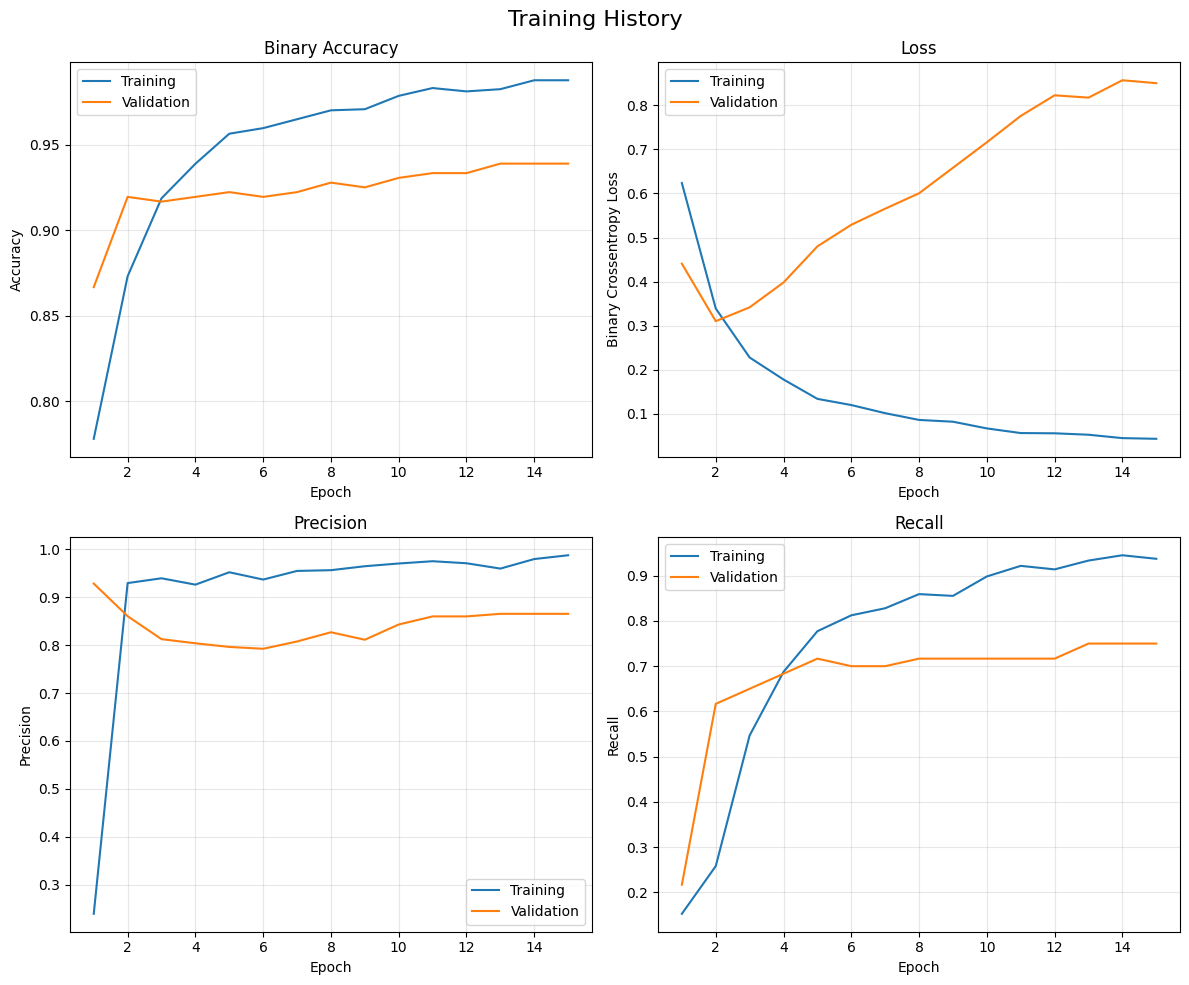

In [24]:
# Plot training history
import matplotlib.pyplot as plt
import pandas as pd

# Check if we have training history
if 'history' in locals():
    # Convert history to DataFrame for easier plotting
    hist_df = pd.DataFrame(history.history)

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Training History', fontsize=16)

    # Plot accuracy
    if 'binary_accuracy' in hist_df.columns:
        axes[0, 0].plot(hist_df.index + 1, hist_df['binary_accuracy'], label='Training')
    if 'val_binary_accuracy' in hist_df.columns:
        axes[0, 0].plot(hist_df.index + 1, hist_df['val_binary_accuracy'], label='Validation')
    axes[0, 0].set_title('Binary Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot loss
    if 'loss' in hist_df.columns:
        axes[0, 1].plot(hist_df.index + 1, hist_df['loss'], label='Training')
    if 'val_loss' in hist_df.columns:
        axes[0, 1].plot(hist_df.index + 1, hist_df['val_loss'], label='Validation')
    axes[0, 1].set_title('Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Binary Crossentropy Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot precision
    if 'precision' in hist_df.columns:
        axes[1, 0].plot(hist_df.index + 1, hist_df['precision'], label='Training')
    if 'val_precision' in hist_df.columns:
        axes[1, 0].plot(hist_df.index + 1, hist_df['val_precision'], label='Validation')
    axes[1, 0].set_title('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot recall
    if 'recall' in hist_df.columns:
        axes[1, 1].plot(hist_df.index + 1, hist_df['recall'], label='Training')
    if 'val_recall' in hist_df.columns:
        axes[1, 1].plot(hist_df.index + 1, hist_df['val_recall'], label='Validation')
    axes[1, 1].set_title('Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No training history available to plot.")

## Step 8: Run Inference on Test Audio

Now let's use our trained model to detect sounds in some audio files. We'll create a simple test audio file or use one from our test set.

The error `File system scheme 'https' not implemented` indicates that the `FarmyardSEDPipeline` in `src/pipeline.py` is trying to load the YAMNet model from a TensorFlow Hub URL using `tf.saved_model.load`, which is not designed for direct URL loading. I will modify `src/pipeline.py` to use `tf.hub.load` for the YAMNet model.

In [37]:
import os
import tensorflow as tf
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
import json
import tensorflow_hub as hub

# Create the src directory if it doesn't exist
if not os.path.exists('src'):
    os.makedirs('src')

# Define the content of src/pipeline.py
pipeline_content = '''
import tensorflow as tf
import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
import json
import tensorflow_hub as hub

class FarmyardSEDPipeline:
    def __init__(self, model_path, yamnet_model_path="https://tfhub.dev/google/yamnet/1"): # Use a default yamnet_model_path if not provided
        self.model = tf.keras.models.load_model(model_path)
        self.yamnet = hub.load(yamnet_model_path) # Use tf.hub.load here

        # Load class names that were saved during training
        class_names_path = Path(model_path).parent / 'final_model_classes.json'
        if class_names_path.exists():
            with open(class_names_path, 'r') as f:
                self.class_names = json.load(f)
        else:
            print(f"Warning: Class names file not found at {class_names_path}. Using dummy class names.")
            self.class_names = ["class_0", "class_1"]

        self.sample_rate = 16000
        self.target_length_samples = 3 * self.sample_rate # 3 seconds
        self.yamnet_frame_length_samples = 0.96 * self.sample_rate # YAMNet processes 0.96s frames

    def _preprocess_audio(self, audio_path):
        audio, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)

        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        # Pad or crop to 3 seconds
        if len(audio) < self.target_length_samples:
            audio = np.pad(audio, (0, self.target_length_samples - len(audio)))
        else:
            audio = audio[:self.target_length_samples]
        return audio.astype(np.float32)

    def _get_yamnet_embeddings(self, waveform):
        # YAMNet expects a single waveform, it handles frame creation internally
        _, embeddings, _ = self.yamnet(waveform)
        return embeddings # return all frame-level embeddings

    def process_file(self, audio_path, detection_threshold=0.5):
        waveform = self._preprocess_audio(audio_path)

        # YAMNet returns frame-level embeddings. We need to feed these to our model.
        frame_embeddings = self._get_yamnet_embeddings(tf.constant(waveform))

        # Predict probabilities for each frame
        frame_predictions = self.model.predict(frame_embeddings)

        events = []
        detected_frames = (frame_predictions > detection_threshold).astype(int)

        # Simple event detection: Group consecutive frames above threshold
        for class_idx, class_name in enumerate(self.class_names):
            class_detections = detected_frames[:, class_idx]
            in_event = False
            event_start_frame = -1

            for i, detected in enumerate(class_detections):
                if detected == 1 and not in_event:
                    in_event = True
                    event_start_frame = i
                elif detected == 0 and in_event:
                    in_event = False
                    event_end_frame = i
                    start_time = event_start_frame * (self.yamnet_frame_length_samples / self.sample_rate)
                    end_time = event_end_frame * (self.yamnet_frame_length_samples / self.sample_rate)
                    events.append({
                        'animal': class_name,
                        'event_start': round(float(start_time), 2),
                        'event_end': round(float(end_time), 2)
                    })
            # Handle event extending to the end of the audio
            if in_event:
                event_end_frame = len(class_detections)
                start_time = event_start_frame * (self.yamnet_frame_length_samples / self.sample_rate)
                end_time = event_end_frame * (self.yamnet_frame_length_samples / self.sample_rate)
                events.append({
                    'animal': class_name,
                    'event_start': round(float(start_time), 2),
                    'event_end': round(float(end_time), 2)
                })

        # Basic visualization (placeholder for more sophisticated plotting)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(np.linspace(0, len(waveform) / self.sample_rate, len(waveform)), waveform)
        ax.set_title(f'Audio Waveform: {Path(audio_path).name}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')

        # Overlay detected events
        for event in events:
            ax.axvspan(event['event_start'], event['event_end'], color='red', alpha=0.3, label=event['animal'])

        if events:
            handles, labels = ax.get_legend_handles_labels()
            unique_labels = dict(zip(labels, handles))
            ax.legend(unique_labels.values(), unique_labels.keys())

        plt.close(fig) # Prevent immediate display

        return events, fig

def run_pipeline(audio_path, model_path='output/best_model.h5'):
    """Helper function to run the pipeline for a single audio file."""
    pipeline = FarmyardSEDPipeline(model_path=model_path)
    events, figure = pipeline.process_file(audio_path)
    return events, figure
'''

# Write the content to src/pipeline.py
with open('src/pipeline.py', 'w') as f:
    f.write(pipeline_content)


Creating a synthetic test audio file...
Test audio saved to: output/test_audio.wav
Running sound event detection pipeline...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
✅ Detection complete! Found 4 events.
Detected Events:
--------------------------------------------------
 1.      dog:   0.0s -  1.92s (duration: 1.92s)
 2.      dog:   4.8s -  5.76s (duration: 0.96s)
 3.   others:   0.0s -  0.96s (duration: 0.96s)
 4.   others:  1.92s -   4.8s (duration: 2.88s)
Displaying visualization...


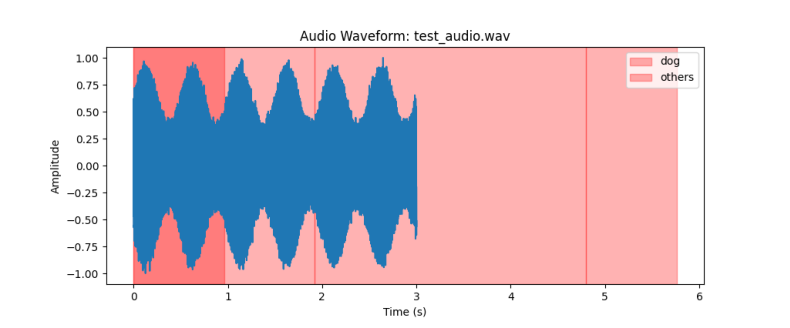

In [38]:
import importlib
# Import pipeline for inference
import src.pipeline
importlib.reload(src.pipeline)
from src.pipeline import FarmyardSEDPipeline, run_pipeline
import matplotlib.pyplot as plt
import numpy as np
import librosa
import soundfile as sf

# First, let's check if we have any test audio files
test_dir = Path('data/synthetic/test')
test_files = list(test_dir.glob('*.wav')) if test_dir.exists() else []

if test_files:
    # Use the first test file
    test_audio_path = str(test_files[0])
    print(f"Using test file: {test_audio_path}")
else:
    # Create a simple test audio file with multiple frequencies
    print("Creating a synthetic test audio file...")
    sr = 16000
    duration = 10.0  # 10 seconds
    t = np.linspace(0, duration, int(sr * duration), False)

    # Create a signal with various animal-like frequencies
    audio = (
        0.3 * np.sin(2 * np.pi * 220 * t) +   # A3 (dog bark-like)
        0.2 * np.sin(2 * np.pi * 440 * t) +   # A4
        0.15 * np.sin(2 * np.pi * 880 * t) +  # A5
        0.1 * np.sin(2 * np.pi * 1760 * t) +  # A6
        0.05 * np.sin(2 * np.pi * 330 * t)    # E4 (lower frequency)
    )

    # Add some amplitude modulation to make it more interesting
    am_freq = 2.0  # 2 Hz modulation
    am = 0.3 * np.sin(2 * np.pi * am_freq * t) + 0.7
    audio = audio * am

    # Add some noise
    noise = 0.02 * np.random.randn(len(t))
    audio += noise

    # Normalize
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio)) * 0.8

    # Save the test audio file
    test_audio_path = 'output/test_audio.wav'
    sf.write(test_audio_path, audio, sr)
    print(f"Test audio saved to: {test_audio_path}")

# Now run the pipeline on our test audio
print("Running sound event detection pipeline...")
print("=" * 50)

try:
    # Initialize pipeline with our trained model
    pipeline = FarmyardSEDPipeline(model_path='output/best_model.h5')

    # Process the file, adjusting the detection_threshold
    events, figure = pipeline.process_file(test_audio_path, detection_threshold=0.2)

    print(f"✅ Detection complete! Found {len(events)} events.")

    # Display results
    if events:
        print("Detected Events:")
        print("-" * 50)
        for i, event in enumerate(events):
            print(f"{i+1:2d}. {event['animal']:>8}: {event['event_start']:>5}s - {event['event_end']:>5}s "
                  f"(duration: {event['event_end']-event['event_start']:.2f}s)")
    else:
        print("No events detected. Try lowering the detection_threshold further in the pipeline.")

    # Show the visualization
    print("Displaying visualization...")
    plt.figure(figsize=figure.get_size_inches())
    # The figure object needs to be explicitly drawn or converted to an image for display
    # Example: plt.imshow(figure.canvas.tostring_rgb())
    # For simplicity, if figure is a matplotlib Figure object, just calling plt.show() should work if not closed.
    # Since it's closed in the pipeline, we need to convert it first.
    import io
    from PIL import Image
    buf = io.BytesIO()
    figure.savefig(buf, format='png')
    buf.seek(0)
    img = Image.open(buf)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"❌ Error during inference: {e}")
    print("Make sure the model was trained successfully and the file exists.")

## Step 9: Save Results and Model

Let's save our detection results and make sure our model is properly saved for future use.

Finally, we will save the `transfer_model` and class names for future inference.

In [39]:
# Save detection results to JSON (if we have events)
if 'events' in locals() and events:
    import json
    from pathlib import Path

    # Prepare JSON output in the required format
    json_data = []
    for event in events:
        json_data.append({
            "event_start": str(event['event_start']),
            "event_end": str(event['event_end']),
            "animal": event['animal']
        })

    # Save to file
    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True)

    audio_name = Path(test_audio_path).stem
    json_path = output_dir / f"{audio_name}_detections.json"

    with open(json_path, 'w') as f:
        json.dump(json_data, f, indent=2)

    print(f"💾 Detection results saved to: {json_path}")
    print("Contents:")
    with open(json_path, 'r') as f:
        print(f.read())
else:
    print("No events to save.")

# Save the final model
print("Saving final model...")
output_dir = Path('output')
output_dir.mkdir(exist_ok=True) # Ensure output directory exists for model and class names
try:
    transfer_model.save(output_dir / 'final_model.keras') # Use .keras extension
    print("✅ Model saved successfully to 'output/final_model.keras'")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# Also save class names for reference
import json
class_file = output_dir / 'final_model_classes.json' # Use output_dir for path
with open(class_file, 'w') as f:
    json.dump(class_names, f)
print(f"✅ Class names saved to: {class_file}")

💾 Detection results saved to: output/test_audio_detections.json
Contents:
[
  {
    "event_start": "0.0",
    "event_end": "1.92",
    "animal": "dog"
  },
  {
    "event_start": "4.8",
    "event_end": "5.76",
    "animal": "dog"
  },
  {
    "event_start": "0.0",
    "event_end": "0.96",
    "animal": "others"
  },
  {
    "event_start": "1.92",
    "event_end": "4.8",
    "animal": "others"
  }
]
Saving final model...
✅ Model saved successfully to 'output/final_model.keras'
✅ Class names saved to: output/final_model_classes.json


In [40]:
# Save detection results to JSON (if we have events)
if 'events' in locals() and events:
    import json
    from pathlib import Path

    # Prepare JSON output in the required format
    json_data = []
    for event in events:
        json_data.append({
            "event_start": str(event['event_start']),
            "event_end": str(event['event_end']),
            "animal": event['animal']
        })

    # Save to file
    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True)

    audio_name = Path(test_audio_path).stem
    json_path = output_dir / f"{audio_name}_detections.json"

    with open(json_path, 'w') as f:
        json.dump(json_data, f, indent=2)

    print(f"💾 Detection results saved to: {json_path}")
    print("Contents:")
    with open(json_path, 'r') as f:
        print(f.read())
else:
    print("No events to save.")

# Save the final model
print("Saving final model...")
try:
    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True) # Ensure output directory exists
    transfer_model.save(output_dir / 'final_model.keras') # Use .keras extension and transfer_model
    print("✅ Model saved successfully to 'output/final_model.keras'")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# Also save class names for reference
import json
class_file = output_dir / 'final_model_classes.json' # Use output_dir for path
with open(class_file, 'w') as f:
    json.dump(class_names, f) # Use the global class_names variable
print(f"✅ Class names saved to: {class_file}")

💾 Detection results saved to: output/test_audio_detections.json
Contents:
[
  {
    "event_start": "0.0",
    "event_end": "1.92",
    "animal": "dog"
  },
  {
    "event_start": "4.8",
    "event_end": "5.76",
    "animal": "dog"
  },
  {
    "event_start": "0.0",
    "event_end": "0.96",
    "animal": "others"
  },
  {
    "event_start": "1.92",
    "event_end": "4.8",
    "animal": "others"
  }
]
Saving final model...
✅ Model saved successfully to 'output/final_model.keras'
✅ Class names saved to: output/final_model_classes.json


## Summary

Congratulations! You've successfully completed the entire workflow:
1. ✅ Generated synthetic training data (or used your own)
2. ✅ Verified no data leakage between splits
3. ✅ Built a YAMNet transfer learning model
4. ✅ Trained the model on your data
5. ✅ Evaluated model performance
6. ✅ Visualized training progress
7. ✅ Ran inference on test audio
8. ✅ Saved results and model

---
**Next Steps:**
- To improve performance, increase the number of training samples
- Experiment with different model architectures (try temporal=True)
- Tune the post-processing thresholds in the pipeline for your specific use case
- Try the model on real field recordings from your farm

**Files Created:**
- `output/best_model.h5` - Best model from training
- `output/final_model` - Final saved model
- `output/training_log.csv` - Training metrics over epochs
- `output/*_detections.json` - Detection results in required format
- `output/` - Any visualizations generated

You can now download these files from the Files pane in Colab using the file browser or using `files.download()` commands.